In [16]:
from typing import TypedDict

In [17]:
class PortfolioState(TypedDict):
    amount_in_usd: float
    amount_total_in_usd: float
    amount_total_in_inr: float

In [18]:
def Calculate_total_usd(state: PortfolioState) -> PortfolioState:
    state['amount_in_usd'] = 1000.0
    state['amount_total_in_usd'] = 1000.0 * 1.08
    return state

In [19]:
def Calculate_total_inr(state: PortfolioState) -> PortfolioState:
    state['amount_total_in_inr'] = state['amount_total_in_usd'] * 92.0
    return state

In [24]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(PortfolioState)

graph_builder.add_node("Calculate_total_usd", Calculate_total_usd)
graph_builder.add_node("Calculate_total_inr",Calculate_total_inr)

graph_builder.add_edge(START, "Calculate_total_usd")

graph_builder.add_edge("Calculate_total_usd", "Calculate_total_inr")

graph_builder.add_edge("Calculate_total_inr", END)

graph = graph_builder.compile()


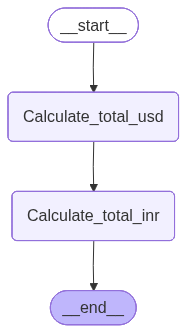

In [28]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))